## Initialize

In [56]:
import pyscf
from pyscf import fci,scf
import numpy as np
from pyscf.fci import cistring


mol = pyscf.M(
    atom = 'O 0 0 0; O 0 0 1.1',  
    basis = 'sto-3g',
    symmetry = True,
    spin = 2,
    
)
myhf = mol.RHF().run()

# #
# # create an FCI solver based on the SCF object
# #
cisolver = pyscf.fci.FCI(myhf)
cie,civ=cisolver.kernel()
print(civ )
num_orbitals = myhf.mo_coeff.shape[1]
print(num_orbitals)
num_alpha_electrons, num_beta_electrons = mol.nelec
print(num_alpha_electrons,num_beta_electrons)
print(civ.shape)

# #
# # create an FCI solver based on the SCF object
# #

# myuhf = mol.UHF().run()
# cisolver = fci.FCI(myuhf)
# e,vec=cisolver.kernel()
# print(e,vec)

#
# # create an FCI solver based on the given orbitals and the num. electrons and
# # spin of the mol object
# #
# cisolver = pyscf.fci.FCI(mol, myhf.mo_coeff)
# print('E(FCI) = ', cisolver.kernel())

alpha_state=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
                           axis=0)
beta_state=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
                           axis=0)
print(alpha_state,beta_state)


# def generate_states(num_orbitals,num_electrons):
#     num_holes=num_orbitals-num_electrons
#     g_state=np.concatenate((np.ones(num_electrons),np.zeros(num_holes)),
#                            axis=0)
#     all=np.array(g_state)
#     max_excitements=np.min(num_electrons,num_holes)
#     for k in range(1,max_excitements+1):
#         for i in range(0,num_electrons):
#             for j in range(num_electrons,num_orbitals):

stra=cistring.addr2str(10,7,10)
print(bin(stra))

converged SCF energy = -147.590894030918
[[ 9.19854131e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  4.92786279e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  2.20629094e-04 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-3.48841749e-05  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
10
9 7
(10, 120)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.] [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
0b101101111


In [57]:
def convert_binary_to_array(strfil, num_orbitals):
    binary_str=str(bin(strfil))
    binary_str = binary_str[2:]
    binary_array = [int(bit) for bit in binary_str]
    leading_zeros = num_orbitals - len(binary_array)
    result_array = [0] * leading_zeros + binary_array
    
    return result_array

# Test the function
# binary_str = "0b11101111"
# result = convert_binary_to_array(stra,10)
# print(result)


In [58]:
from itertools import combinations
from jax import numpy as jnp

# def generate_states(num_orbitals,num_electrons):
#     configs = []
#     for indices in combinations(range(num_orbitals), num_electrons):
#         box_config = [1 if i in indices else 0 for i in range(num_orbitals)]
#         configs.append(box_config)
#     return np.array(configs)

def generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,ci):
    # alpha_states=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
    #                        axis=0)
    # beta_states=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
    #                        axis=0)
    
    # alpha_states=generate_states(num_orbitals,num_alpha_electrons)
    # beta_states=generate_states(num_orbitals,num_beta_electrons)
    x=[]
    y=[]
    # print(ci.shape[0])
    for i in range(ci.shape[0]):
        for j in range(ci.shape[1]):
                
            y.append(ci[i,j])
            #print(num_orbitals,num_alpha_electrons,i)
            orba=cistring.addr2str(num_orbitals,num_alpha_electrons,i)
            orbb=cistring.addr2str(num_orbitals,num_beta_electrons,j)
            
            orba=convert_binary_to_array(orba,num_orbitals)
            orbb=convert_binary_to_array(orbb,num_orbitals)
            x.append(np.concatenate((orba,orbb),axis=0))
    x=jnp.array(x)
    y=jnp.array(y)
    return x,y



# num_orbs = 10
# num_e = 7
# config_list = generate_states(num_orbs, num_e)

# print(generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ))



## MLP NN

In [106]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
from jax import random
import matplotlib.pyplot as plt

class NN1(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=64)(x)  
        x = nn.relu(x)
        x = nn.Dense(features=6)(x)    
        x= nn.relu(x)
        x = nn.Dense(features=1)(x) 
        # print(x.shape)
        return x             


def create_model_MLP(rng, input_shape):
    model = NN1()
    variables = model.init(rng, jnp.ones(input_shape))
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    return jnp.mean((preds - y) ** 2)


@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    #print(loss_fn(state.params),grads)
    return state, loss_fn(state.params)


def create_train_state_MLP(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


# Check Neural network functions
# def generate_random_data(rng, num_samples, input_size):    
#     x = random.randint(rng, (num_samples, input_size), 0, 2)
#     y = random.uniform(rng, (num_samples, 1), float,-1, 1)
#     return x, y




Epoch 1, Loss: 0.008019215427339077
Epoch 2, Loss: 0.0032074504997581244
Epoch 3, Loss: 0.0018706447444856167
Epoch 4, Loss: 0.001434559584595263
Epoch 5, Loss: 0.0012368786847218871
Epoch 6, Loss: 0.0010669123148545623
Epoch 7, Loss: 0.0009844221640378237
Epoch 8, Loss: 0.0009388019680045545
Epoch 9, Loss: 0.0009073197725228965
Epoch 10, Loss: 0.0009096394060179591
Epoch 11, Loss: 0.0008859459776431322
Epoch 12, Loss: 0.0008611978846602142
Epoch 13, Loss: 0.0008391171577386558
Epoch 14, Loss: 0.0008267189259640872
Epoch 15, Loss: 0.0008181417360901833
Epoch 16, Loss: 0.0008049967582337558
Epoch 17, Loss: 0.0007785256020724773
Epoch 18, Loss: 0.0007405137293972075
Epoch 19, Loss: 0.0007004084181971848
Epoch 20, Loss: 0.0006524784257635474
Epoch 21, Loss: 0.0006338758976198733
Epoch 22, Loss: 0.0006013980018906295
Epoch 23, Loss: 0.0005169248906895518
Epoch 24, Loss: 0.00045401082024909556
Epoch 25, Loss: 0.00039492477662861347
Epoch 26, Loss: 0.0003730757161974907
Epoch 27, Loss: 0.000

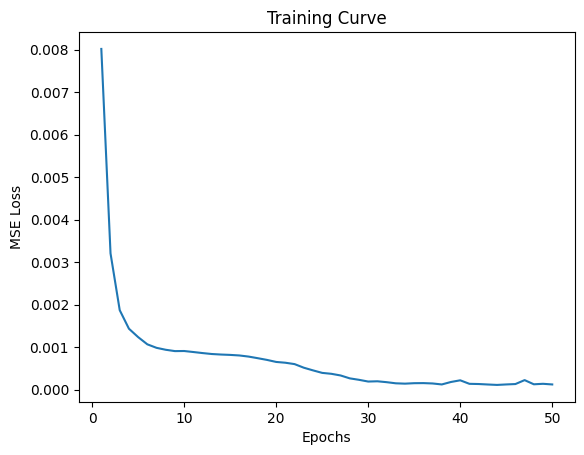

Training complete


In [102]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals # Example input size
    num_samples = len(y_train) # Number of training samples
    
    model_mlp, variables_mlp = create_model_MLP(rng, (input_size,))
    state_MLP = create_train_state_MLP(rng, model_mlp, variables_mlp)
    
    # Training loop
    num_epochs = 50
    batch_size = 1
    train_losses_MLP = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state_MLP, loss = train_step(state_MLP, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses_MLP.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses_MLP)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

## BACKFLOW CODE 1
DO NOT Change

In [6]:
class BACKFLOW(nn.Module):
    # features: Sequence[int] 
    num_orbital:int
    num_electron:int

    # def setup(self):
    #    self.layers = [nn.Dense(n) for n in self.features]
    @nn.compact
    def __call__(self, x):
        # for i, lyr in enumerate(self.layers):
        #   x = lyr(x)
        #   if i != len(self.layers) - 1:
        #     x = nn.relu(x) 
        # # TODO: select corresponding rows and columns of the matrix
        # MLP
        # x = jnp.reshape(x,(20,1))
        y = jnp.copy(x)
        #print(y)
        #print("yshape",y.shape,y)
        selected_configs =jnp.where(y==1)[0]
        # for j, yj in enumerate(y):
        #     # print(yj)
        #     if yj==1:
        #         selected_configs.append(j)
        
                
        x = nn.Dense(features=8)(x)  
        x = nn.relu(x)
        
        #Backflow
        #print(type(x),x.shape)
        x = nn.DenseGeneral(features=(self.num_orbital,self.num_electron))(x)
        #print(x.shape)
        # print(x.shape,self.num_orbital,self.num_electron,)
        #print(type(x),x.shape)
        x = x[:,selected_configs , :]
        #print(jnp.array(selected_configs).shape)
        
        #x=nn.Dense(features=1)(x)
        # x = jnp.linalg.det(x)
        # x = jnp.array([x])
        #print(type(x),x.shape)
        return x

def create_model(rng, input_shape,num_electrons): #input shape = #orbitals total
    model = BACKFLOW(num_orbital=input_shape,num_electron=num_electrons)
    initial=jnp.concatenate((jnp.ones((num_electrons,)),
                                                 jnp.zeros((input_shape-num_electrons,))),axis=0)
    initial=jnp.reshape(initial,(1,input_shape))
    variables = model.init(rng,initial )
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):
    preds = apply_fn({'params': params}, x)
    #print("preds shape",preds.shape)
    return jnp.mean((jnp.linalg.det(preds) - y) ** 2)
    
    # return jnp.mean((preds - y) ** 2)


#@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        #print(loss)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


In [7]:
# Main function
def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals 
    num_samples = len(y_train) 
    
    model, variables = create_model(rng, input_size,
                                    num_electrons=num_alpha_electrons+num_beta_electrons)
    state = create_train_state(rng, model, variables)
    
    # Training loop
    num_epochs = 50
    batch_size = 1
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

Epoch 1, Loss: 0.0008333335281349719


KeyboardInterrupt: 

In [ ]:
# y=jnp.array([1,0,1,1,1,0])
# selected_configs =jnp.where(y==1)[0]
# print(selected_configs)

## Back Flow CODE 2
- 1 Error Grads are 0 (Machine Not Learning)
- 2 Issue Jit(grad) not working (slow compilation)

In [112]:
from jax.nn.initializers import normal
class BACKFLOW(nn.Module):

    num_orbital:int
    num_electron:int

    @nn.compact
    def __call__(self, x):
        
        #y = jnp.copy(x)
        mask = jnp.where(x == 1, 1, 0)
        selected_config = jnp.nonzero(mask, size=self.num_electron)[1]
        
        x = nn.Dense(features=4)(x)  
        x = nn.tanh(x)
        x = nn.Dense(features=4)(x)  

        x = nn.tanh(x)
        
        #Backflow
        x = nn.DenseGeneral(features=(self.num_orbital,self.num_electron))(x)
        x = nn.tanh(x)
        
        x = x[:,selected_config , :]
        #print(jnp.linalg.det(x))
        return jnp.linalg.det(x)
    
def row_select(y):
    selected_configs=[]
    for j, yj in enumerate(y):
            # print(yj)
            if yj==1:
                selected_configs.append(j)
    return selected_configs

def create_model(rng, input_shape,num_electrons): #input shape = #orbitals total
    model = BACKFLOW(num_orbital=input_shape,num_electron=num_electrons)
    initial=jnp.concatenate((jnp.ones((num_electrons,)),
                                                 jnp.zeros((input_shape-num_electrons,))),axis=0)
    initial=jnp.reshape(initial,(1,input_shape))
    variables = model.init(rng,initial)#initializer=normal 
    return model, variables

# Define the mean squared error (MSE) loss function
def mse_loss(params, apply_fn, x, y):    
    preds = apply_fn({'params': params}, x)
    return jnp.mean((preds - y) ** 2)


@jax.jit
def train_step(state, batch):
    def loss_fn(params):
        x, y = batch
        loss = mse_loss(params, state.apply_fn, x, y)
        #print(loss)
        return loss
    grads = jax.grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    #print(loss_fn(state.params),grads)
    return state, loss_fn(state.params)


def create_train_state(rng, model, variables):
    tx = optax.adam(learning_rate=0.001)
    return train_state.TrainState.create(apply_fn=model.apply, params=variables['params'], tx=tx)


Epoch 1, Loss: 0.0048380461521446705
Epoch 2, Loss: 0.0009117330773733556
Epoch 3, Loss: 0.0008740680059418082
Epoch 4, Loss: 0.0008615811238996685
Epoch 5, Loss: 0.0008537227986380458
Epoch 6, Loss: 0.0008484694408252835
Epoch 7, Loss: 0.0008448229636996984
Epoch 8, Loss: 0.0008422175887972116
Epoch 9, Loss: 0.0008403132087551057
Epoch 10, Loss: 0.0008388955029658973
Epoch 11, Loss: 0.0008378222119063139
Epoch 12, Loss: 0.0008370000286959112
Epoch 13, Loss: 0.000836362421978265
Epoch 14, Loss: 0.0008358638733625412
Epoch 15, Loss: 0.0008354683523066342
Epoch 16, Loss: 0.0008351510623469949
Epoch 17, Loss: 0.0008348922128789127
Epoch 18, Loss: 0.0008346797549165785
Epoch 19, Loss: 0.0008345007663592696
Epoch 20, Loss: 0.0008343485533259809
Epoch 21, Loss: 0.0008342175278812647
Epoch 22, Loss: 0.0008341033826582134
Epoch 23, Loss: 0.0008340027998201549
Epoch 24, Loss: 0.0008339133346453309
Epoch 25, Loss: 0.0008338334737345576
Epoch 26, Loss: 0.0008337603649124503
Epoch 27, Loss: 0.0008

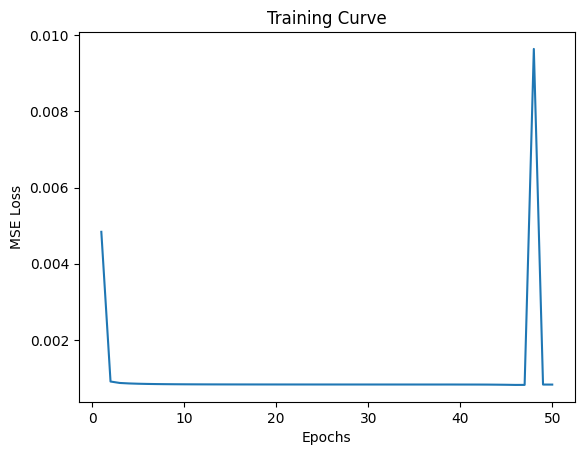

Training complete


In [99]:
# Main function

def main():
    rng = random.PRNGKey(7)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals 
    num_samples = len(y_train) 
    
    model, variables = create_model(rng, input_size,
                                    num_electrons=num_alpha_electrons+num_beta_electrons)
    state = create_train_state(rng, model, variables)
    #print(variables)
    # Training loop
    num_epochs = 50
    batch_size = 5
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve')
    plt.show()
    #plt.plot(x_tra,y_train)
    print("Training complete")

if __name__ == "__main__":
    main()

##### Identification of error
- grad for jax.linalg.det is 0
- not a problem with determinant check other stuff


In [36]:
import numpy as np
#@jax.jit
def newcheck(a,b):
    #a=np.array(a)
    b=jnp.array(b,dtype=int)
    b =jnp.where(b==1)[0]
    a=a[b]
    #c=len(a)
    e=jnp.array([jnp.power(a,i) for i in range(1,a.shape[0]+1)])
    #d=jnp.outer(a,jnp.array([3,5]))
    #print(d.shape)
    print(e)
    return jnp.linalg.det(e)

print(newcheck(jnp.array([5.,2.,3.]),[0,1,1]))

print(jax.grad(newcheck,0)(jnp.array([5, 2, 3],dtype=float),[0,1,1]))


[[2. 3.]
 [4. 9.]]
6.0
Traced<ConcreteArray([[2. 3.]
 [4. 9.]], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([[2., 3.],
       [4., 9.]], dtype=float32)
  tangent = Traced<ShapedArray(float32[2,2])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[2,2]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x776373b98a40>, in_tracers=(Traced<ShapedArray(float32[2,2]):JaxprTrace(level=1/0)>,), out_tracer_refs=[<weakref at 0x77638cc6b100; to 'JaxprTracer' at 0x77638cc69b30>], out_avals=[ShapedArray(float32[2,2])], primitive=convert_element_type, params={'new_dtype': dtype('float32'), 'weak_type': False}, effects=frozenset(), source_info=SourceInfo(traceback=<jaxlib.xla_extension.Traceback object at 0x1082b050>, name_stack=NameStack(stack=(Transform(name='jvp'),))))
[ 0. -3.  8.]


In [78]:
import jax
import jax.numpy as jnp

# Define the JAX-compatible row_select function
@jax.jit
def row_select(y):
    # Create a boolean mask where y == 1
    mask = jnp.where(y == 1, 1, 0)
    # Get the indices of elements where the mask is 1
    selected_configs = jnp.nonzero(mask, )[0]
    return selected_configs

# Example input array
y = jnp.array([0, 1, 0, 1, 1])

# Trace the computation using JAXpr
#jaxpr = jax.make_jaxpr(row_select)(y)
#print(jaxpr)

# Run the function
selected_configs = row_select(y)
print(selected_configs)


ConcretizationTypeError: Abstract tracer value encountered where concrete value is expected: traced array with shape int32[].
The size argument of jnp.nonzero must be statically specified to use jnp.nonzero within JAX transformations.
The error occurred while tracing the function row_select at /tmp/ipykernel_11291/1830782612.py:5 for jit. This concrete value was not available in Python because it depends on the value of the argument y.

See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.ConcretizationTypeError

Epoch 1, Loss: 688.07958984375
Epoch 2, Loss: 32.13861083984375
Epoch 3, Loss: 18.39173126220703
Epoch 4, Loss: 12.480633735656738
Epoch 5, Loss: 9.179516792297363
Epoch 6, Loss: 7.111677646636963
Epoch 7, Loss: 5.71282434463501
Epoch 8, Loss: 4.713207721710205
Epoch 9, Loss: 3.969099283218384
Epoch 10, Loss: 3.3974111080169678
Epoch 11, Loss: 2.9469919204711914
Epoch 12, Loss: 2.584740400314331
Epoch 13, Loss: 2.288351535797119
Epoch 14, Loss: 2.0423097610473633
Epoch 15, Loss: 1.8354896306991577
Epoch 16, Loss: 1.6597446203231812
Epoch 17, Loss: 1.50897216796875
Epoch 18, Loss: 1.3785206079483032
Epoch 19, Loss: 1.2647970914840698
Epoch 20, Loss: 1.1649799346923828
Epoch 21, Loss: 1.0768290758132935
Epoch 22, Loss: 0.9985413551330566
Epoch 23, Loss: 0.9286551475524902
Epoch 24, Loss: 0.8659753203392029
Epoch 25, Loss: 0.8095151782035828
Epoch 26, Loss: 0.7584522366523743
Epoch 27, Loss: 0.7120959162712097
Epoch 28, Loss: 0.6698697209358215
Epoch 29, Loss: 0.631279706954956
Epoch 30, 

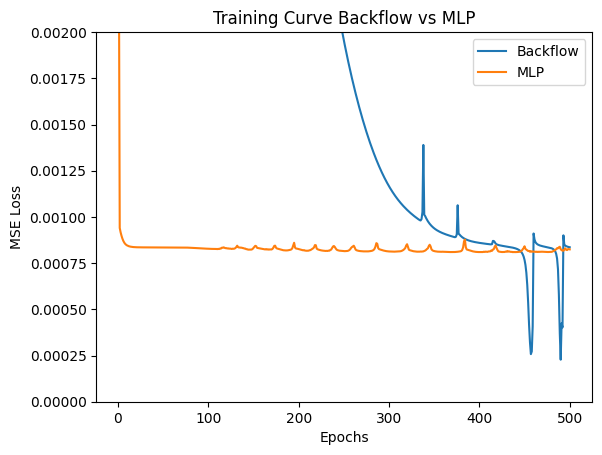

In [118]:
# Main function

def main():
    rng = random.PRNGKey(15)
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals 
    num_samples = len(y_train) 
    
    model, variables = create_model(rng, input_size,
                                    num_electrons=num_alpha_electrons+num_beta_electrons)
    state = create_train_state(rng, model, variables)
    #print(variables)
    # Training loop
    num_epochs = 500
    batch_size = 25
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state, loss = train_step(state, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses, label="Backflow")
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training Curve Backflow vs MLP')
    
    #plt.plot(x_tra,y_train)
    print("Training complete _backflow")
    
    
    x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
    input_size = 2*num_orbitals # Example input size
    num_samples = len(y_train) # Number of training samples
    
    model_mlp, variables_mlp = create_model_MLP(rng, (input_size,))
    state_MLP = create_train_state_MLP(rng, model_mlp, variables_mlp)
    
    # Training loop
    # num_epochs = 50
    # batch_size = 5
    train_losses_MLP = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
            state_MLP, loss = train_step(state_MLP, batch)
            epoch_loss += loss
        
        average_epoch_loss = epoch_loss / (num_samples // batch_size)
        train_losses_MLP.append(average_epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")
    
    # Plotting the training curve
    plt.plot(range(1, num_epochs + 1), train_losses_MLP, label="MLP")
    plt.legend(loc="upper right")
    plt.ylim(0,0.002)
    plt.show()
    
    #plt.plot(x_tra,y_train)
    
    

if __name__ == "__main__":
    main()